# Tutorial: Predicting subcellular compartments with C-COMPASS

*grassp* can drive [C-COMPASS](https://github.com/ICB-DCM/C-COMPASS) (Haas et al.,
*Nature Methods* 2025), a neural-network classifier that assigns each protein a
*class contribution* over subcellular compartments from fractionation profiles. Because
the contributions for a protein sum to 1, C-COMPASS naturally reports **multi-localizing**
proteins.

In this tutorial we run C-COMPASS on the Haas 2025 humanized-liver dataset through
`grassp`, using both the quick **median** workflow and the paper-faithful **per-replicate**
workflow, and visualize the predictions on a UMAP.

## Installation

The C-COMPASS integration is an optional extra (it pulls in TensorFlow/Keras). Install it
with:

> `pip install grassp[ccompass]`

TensorFlow currently provides wheels for Python ≤ 3.13, so use a 3.12/3.13 environment.
The rest of `grassp` does not require this extra.

In [1]:
# Spatial and single-cell analysis
import grassp as gr
import scanpy as sc

# Numerical computing
import numpy as np
import pandas as pd

## Loading the data

We use `gr.ds.load_dataset` to pull curated datasets from the grassp portal by name.
`enrichment="enriched"` returns the processed object — for this dataset that is the
replicate-median fractionation profile with a precomputed UMAP and the authors' marker
compartments in `obs["author_annotation"]`.

In [2]:
adata = gr.ds.load_dataset("Haas_2025_HumanizedLiver_Chow", enrichment="enriched")
adata

AnnData object with n_obs × n_vars = 6117 × 14
    obs: 'author_gene_symbol', 'ProteinGroups', 'uniprot_id', 'author_annotation', 'marker_lilley', 'marker_christopher', 'marker_geladaki', 'marker_itzhak', 'marker_villaneuva', 'marker_hein2025', 'marker_hein2025_gt', 'n_replicates_with_minimum_3_fractions', 'n_samples_by_intensity', 'mean_intensity', 'log1p_mean_intensity', 'pct_dropout_by_intensity', 'total_intensity', 'log1p_total_intensity'
    var: 'replicate', 'fraction_order', 'fraction', 'n_proteins_by_intensity', 'log1p_n_proteins_by_intensity', 'total_intensity', 'log1p_total_intensity', 'pct_dropout_by_intensity', 'subcellular_enrichment', 'n_merged_samples', 'enriched_vs'
    uns: 'author_annotation_colors', 'marker_christopher_colors', 'marker_geladaki_colors', 'marker_hein2025_colors', 'marker_hein2025_gt_colors', 'marker_itzhak_colors', 'marker_lilley_colors', 'marker_villaneuva_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap3D'
    varm: 'PCs'
   

The authors' marker compartments already separate cleanly on the UMAP:

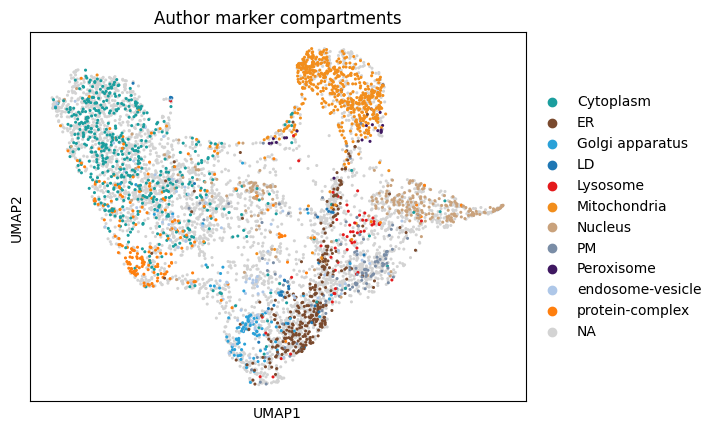

In [3]:
sc.pl.umap(adata, color="author_annotation", title="Author marker compartments")

## Inspecting the C-COMPASS parameters

`gr.tl.ccompass_default_params()` returns the hyperparameters C-COMPASS will use (network,
training, and the reliability filter). Every field is overridable via the `nn_params`
argument (a dict, a `NeuralNetworkParametersModel`, or a path to a YAML file). grassp
defaults `NN_optimization="short"` to match the paper.

In [4]:
gr.tl.ccompass_default_params()

NeuralNetworkParametersModel(upsampling=True, upsampling_method='noisedaverage', upsampling_noise=2, svm_filter=False, mixed_part=4, mixed_batch=0.05, NN_optimization='short', NN_activation='relu', class_activation='linear', class_loss='mean_squared_error', optimizers=['adam', 'rmsprop', 'sgd'], NN_epochs=20, rounds=3, subrounds=10, reliability=95)

## Simple workflow (median profiles)

The enriched object has a single (median) profile per protein, so we call `gr.tl.ccompass`
with `aggregate=False`: C-COMPASS trains on the marker proteins in `author_annotation` and
predicts a compartment for every protein.

Here we deliberately shrink `rounds`/`subrounds` so the tutorial runs quickly; the defaults
shown above (`rounds=3`, `subrounds=10`) reproduce the paper.

In [5]:
fast = {"rounds": 1, "subrounds": 5}
gr.tl.ccompass(adata, marker_key="author_annotation", aggregate=False, nn_params=fast)
adata

AnnData object with n_obs × n_vars = 6117 × 14
    obs: 'author_gene_symbol', 'ProteinGroups', 'uniprot_id', 'author_annotation', 'marker_lilley', 'marker_christopher', 'marker_geladaki', 'marker_itzhak', 'marker_villaneuva', 'marker_hein2025', 'marker_hein2025_gt', 'n_replicates_with_minimum_3_fractions', 'n_samples_by_intensity', 'mean_intensity', 'log1p_mean_intensity', 'pct_dropout_by_intensity', 'total_intensity', 'log1p_total_intensity', 'ccompass'
    var: 'replicate', 'fraction_order', 'fraction', 'n_proteins_by_intensity', 'log1p_n_proteins_by_intensity', 'total_intensity', 'log1p_total_intensity', 'pct_dropout_by_intensity', 'subcellular_enrichment', 'n_merged_samples', 'enriched_vs'
    uns: 'author_annotation_colors', 'marker_christopher_colors', 'marker_geladaki_colors', 'marker_hein2025_colors', 'marker_hein2025_gt_colors', 'marker_itzhak_colors', 'marker_lilley_colors', 'marker_villaneuva_colors', 'neighbors', 'pca', 'umap', 'ccompass_nn_params', 'ccompass_categories', '

`ccompass` writes the winning compartment to `obs["ccompass"]`, the full
class-contribution matrix to `obsm["ccompass_contributions"]`, and the compartment order to
`uns["ccompass_categories"]`. The predicted map closely matches the author markers:

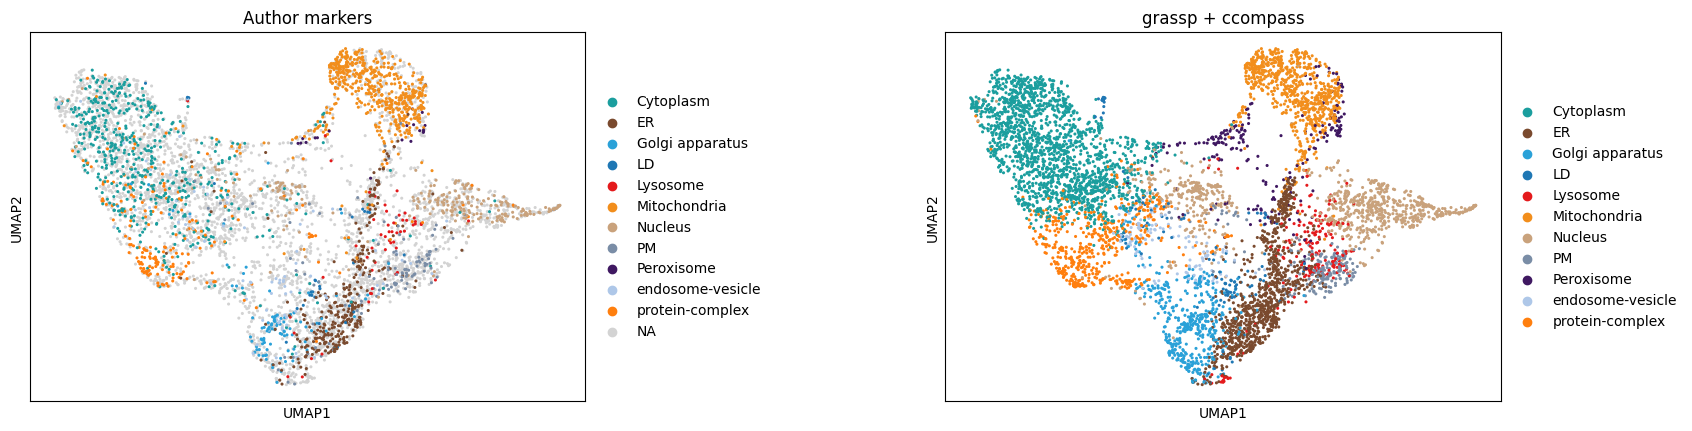

In [6]:
sc.pl.umap(
    adata,
    color=["author_annotation", "ccompass"],
    title=["Author markers", "grassp + ccompass"],
    wspace=0.5,
)

Because the output is a probability-like vector, we can also weight each point by its
prediction confidence (the top class contribution) using grassp's `umap_prob`:

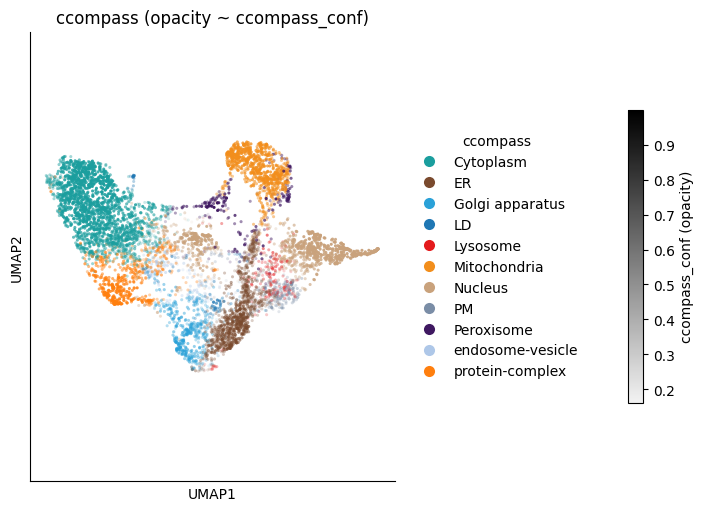

<Axes: title={'center': 'ccompass (opacity ~ ccompass_conf)'}, xlabel='UMAP1', ylabel='UMAP2'>

In [7]:
adata.obs["ccompass_conf"] = adata.obsm["ccompass_contributions"].max(axis=1)
gr.pl.umap_prob(adata, color="ccompass", color_prob="ccompass_conf")

## Faithful workflow (per-replicate + reliability filtering)

The paper trains a network **per replicate** and then applies a reliability filter (fCC)
that removes spurious contributions using cross-replicate behaviour. This needs the
individual replicates, which we get with `enrichment="raw"`.

In [8]:
raw = gr.ds.load_dataset("Haas_2025_HumanizedLiver_Chow", enrichment="raw")
raw

AnnData object with n_obs × n_vars = 8833 × 42
    obs: 'author_gene_symbol', 'ProteinGroups', 'uniprot_id', 'author_annotation', 'marker_lilley', 'marker_christopher', 'marker_geladaki', 'marker_itzhak', 'marker_villaneuva', 'marker_hein2025', 'marker_hein2025_gt'
    var: 'replicate', 'fraction', 'fraction_order'
    uns: 'author_annotation_colors', 'condition', 'marker_christopher_colors', 'marker_geladaki_colors', 'marker_hein2025_colors', 'marker_hein2025_gt_colors', 'marker_itzhak_colors', 'marker_lilley_colors', 'marker_villaneuva_colors', 'replicates'

C-COMPASS's classification input is normalized so each replicate profile sums to 1
(missing values treated as 0), and proteins seen in fewer than two replicates are dropped.
We apply that normalization, then run `ccompass` with `replicate_key="replicate"` and
`aggregate=True` (and `scale=False`, since we normalized ourselves).

In [9]:
def area_normalize_per_replicate(a):
    """missing -> 0, then normalize each replicate profile to sum 1; keep proteins in >=2 reps."""
    X = np.asarray(a.X, dtype=float)
    reps = a.var["replicate"].values
    identified = np.zeros(a.n_obs, dtype=int)
    for g in np.unique(reps):
        cols = np.where(reps == g)[0]
        block = np.nan_to_num(X[:, cols], nan=0.0)
        identified += (block != 0).any(axis=1).astype(int)
        s = block.sum(axis=1, keepdims=True)
        X[:, cols] = np.divide(block, s, out=np.zeros_like(block), where=s > 0)
    a.X = X
    return a[identified >= 2].copy()

raw = area_normalize_per_replicate(raw)
raw

AnnData object with n_obs × n_vars = 7871 × 42
    obs: 'author_gene_symbol', 'ProteinGroups', 'uniprot_id', 'author_annotation', 'marker_lilley', 'marker_christopher', 'marker_geladaki', 'marker_itzhak', 'marker_villaneuva', 'marker_hein2025', 'marker_hein2025_gt'
    var: 'replicate', 'fraction', 'fraction_order'
    uns: 'author_annotation_colors', 'condition', 'marker_christopher_colors', 'marker_geladaki_colors', 'marker_hein2025_colors', 'marker_hein2025_gt_colors', 'marker_itzhak_colors', 'marker_lilley_colors', 'marker_villaneuva_colors', 'replicates'

In [10]:
gr.tl.ccompass(
    raw,
    marker_key="author_annotation",
    replicate_key="replicate",
    aggregate=True,
    scale=False,
    nn_params=fast,
)
raw

AnnData object with n_obs × n_vars = 7871 × 42
    obs: 'author_gene_symbol', 'ProteinGroups', 'uniprot_id', 'author_annotation', 'marker_lilley', 'marker_christopher', 'marker_geladaki', 'marker_itzhak', 'marker_villaneuva', 'marker_hein2025', 'marker_hein2025_gt', 'ccompass', 'ccompass_fwinner'
    var: 'replicate', 'fraction', 'fraction_order'
    uns: 'author_annotation_colors', 'condition', 'marker_christopher_colors', 'marker_geladaki_colors', 'marker_hein2025_colors', 'marker_hein2025_gt_colors', 'marker_itzhak_colors', 'marker_lilley_colors', 'marker_villaneuva_colors', 'replicates', 'ccompass_nn_params', 'ccompass_categories', 'ccompass_colors', 'ccompass_fwinner_colors'
    obsm: 'ccompass_contributions', 'ccompass_fcontributions'

With `aggregate=True` you additionally get the reliability-filtered contributions in
`obsm["ccompass_fcontributions"]` and the filtered winner in `obs["ccompass_fwinner"]`.
We transfer the filtered winner onto the enriched object (shared UniProt ids) to plot it on
the same UMAP:

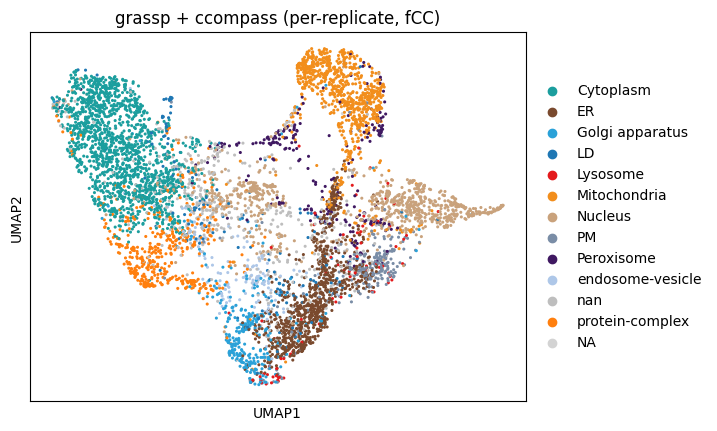

In [11]:
adata.obs["ccompass_fwinner"] = (
    raw.obs["ccompass_fwinner"].reindex(adata.obs_names).astype("category")
)
gr.pp.set_sensible_compartment_colors(adata, columns=["ccompass_fwinner"])
sc.pl.umap(adata, color="ccompass_fwinner", title="grassp + ccompass (per-replicate, fCC)")

Finally, we flag multi-localizing proteins — those whose second-highest filtered
contribution exceeds a threshold — and highlight them on the UMAP:

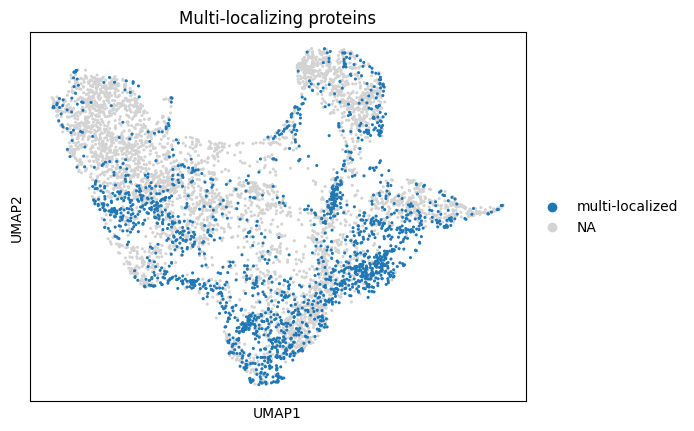

In [12]:
fcc = np.asarray(raw.obsm["ccompass_fcontributions"], dtype=float)
second = np.sort(fcc, axis=1)[:, ::-1][:, 1]
multi = pd.Series(np.where(second > 0.2, "multi-localized", "single"), index=raw.obs_names)

adata.obs["ccompass_multiloc"] = multi.reindex(adata.obs_names).astype("category")
sc.pl.umap(adata, color="ccompass_multiloc", groups=["multi-localized"],
           title="Multi-localizing proteins")

## Median vs. faithful — which to use?

- **Median (`aggregate=False`)** is a fast approximation: one network on the collapsed
  profile, raw contributions only. Good for a quick look.
- **Per-replicate (`replicate_key=..., aggregate=True`)** matches the paper: a network per
  replicate plus the reliability (fCC) filter, which uses replicate reproducibility to
  separate genuine localization from noise — giving cleaner assignments and
  multi-localization calls.

Use the median workflow to explore, and the per-replicate workflow when you want results
that reproduce the published C-COMPASS output.